# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





**Github Repository**: https://github.com/ColombeIgihozo/Principle-Component-Analysis-PCA--Group-45




### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

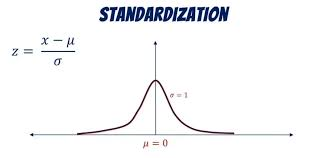


In [15]:
import numpy as np
import csv

filename = "drc_ebola_outbreak.csv"   # same folder as the notebook

# read every row in
with open(filename, "r", encoding="latin-1") as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [r for r in reader if len(r) == len(header)]   # skip broken rows

print("Columns:", header)
print("Rows read:", len(rows))

Columns: ['report_date', 'country', 'province', 'health_zone', 'new_confirmed', 'new_probable', 'confirmed_cases', 'probable_cases', 'confirmed_deaths', 'total_deaths', 'recovered', 'contacts_followed']
Rows read: 454


In [16]:
# label-encode the province column (our non-numeric feature)
prov_i = header.index("province")
provinces = sorted(set(r[prov_i] for r in rows))
province_map = {name: i for i, name in enumerate(provinces)}
print("Province encoding:", province_map)

# columns we treat as text and skip in the numeric matrix
text_cols = ["report_date", "country", "province", "health_zone"]
numeric_cols = [c for c in header if c not in text_cols]

# features that go into PCA = encoded province + the numeric columns
feature_names = ["province_code"] + numeric_cols
print("\nFeatures used for PCA:", feature_names)

Province encoding: {'Ituri': 0, 'North Kivu': 1, 'Sud Kivu': 2}

Features used for PCA: ['province_code', 'new_confirmed', 'new_probable', 'confirmed_cases', 'probable_cases', 'confirmed_deaths', 'total_deaths', 'recovered', 'contacts_followed']


In [17]:
# build the numeric matrix X, turning blanks into np.nan
data = []
for r in rows:
    new_row = [province_map[r[prov_i]]]          # encoded province first
    for c in numeric_cols:
        val = r[header.index(c)].strip()
        if val == "" or val.upper() in ("NA", "NAN", "NULL"):
            new_row.append(np.nan)
        else:
            new_row.append(float(val))
    data.append(new_row)

X = np.array(data, dtype=float)
print("Matrix shape (rows, cols):", X.shape)
print("Missing values before imputation:", int(np.isnan(X).sum()))

Matrix shape (rows, cols): (454, 9)
Missing values before imputation: 228


In [18]:
# fill missing values with each column's mean (mean imputation)
col_means = np.nanmean(X, axis=0)
nan_rows, nan_cols = np.where(np.isnan(X))
X[nan_rows, nan_cols] = col_means[nan_cols]

print("Missing values after imputation:", int(np.isnan(X).sum()))
print("First row of clean data:", np.round(X[0], 1))

Missing values after imputation: 0
First row of clean data: [  0.  19.   2. 607. 614. 296. 301. 310. 323.]


### Data Loading Issue

It appears that the `DRC_Ebola_data.csv` file is not a standard CSV file. The data loading process resulted in an empty dataset, likely because the file contains binary or corrupted content (e.g., it might be a compressed file or an Excel file saved with a `.csv` extension but not in a plain text CSV format).

To proceed with the notebook and perform PCA, please ensure you provide a valid, plain text CSV file. Once a correct file is loaded, I can continue with the subsequent steps of data standardization, covariance matrix calculation, eigendecomposition, and PCA projection.

In [19]:
mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1.0          # avoid divide-by-zero on constant columns

Z = (X - mean) / std

print("Means after standardizing (should be ~0):", np.round(Z.mean(axis=0), 3))
print("Stds  after standardizing (should be ~1):", np.round(Z.std(axis=0), 3))
print("\nFirst 5 standardized rows:")
print(np.round(Z[:5], 3))

Means after standardizing (should be ~0): [ 0. -0.  0.  0.  0. -0. -0.  0. -0.]
Stds  after standardizing (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]

First 5 standardized rows:
[[-1.215 -0.468 -0.6   -0.017 -0.017  0.111  0.133 -0.042 -0.347]
 [-1.215 -0.815 -0.6   -0.019 -0.011 -0.009 -0.     0.047 -0.647]
 [ 0.199 -0.685 -0.857 -1.207 -1.188 -0.    -1.195 -1.192 -0.46 ]
 [ 0.199 -0.337 -0.6   -0.719 -0.704 -0.689 -0.664 -0.784 -0.27 ]
 [-1.215 -0.424 -0.6   -0.071 -0.069 -0.041 -0.044 -0.076 -0.723]]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [20]:
# np.cov expects features in rows, so we transpose
cov = np.cov(Z.T)
print("Covariance matrix shape:", cov.shape)
print("\nTop-left 4x4 corner:")
print(np.round(cov[:4, :4], 2))

Covariance matrix shape: (9, 9)

Top-left 4x4 corner:
[[1.   0.13 0.07 0.31]
 [0.13 1.   0.8  0.17]
 [0.07 0.8  1.   0.14]
 [0.31 0.17 0.14 1.  ]]


The covariance matrix quantifies how features vary together, showing positive covariance for features that increase or decrease simultaneously, and negative for those that move in opposite directions. It is crucial for PCA because it directly provides the variance and relationships between all pairs of features, which are then used to find the principal components. It captures the spread and orientation of the data.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)

print("Eigenvalues (unsorted):")
print(np.round(eigenvalues, 3))
print("\nEigenvector matrix shape:", eigenvectors.shape)

Eigenvalues (unsorted):
[0.047 0.058 0.072 0.127 0.152 0.263 0.894 2.445 4.963]

Eigenvector matrix shape: (9, 9)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [22]:
order = np.argsort(eigenvalues)[::-1]        # indices, largest first
sorted_eigenvalues  = eigenvalues[order]
sorted_eigenvectors = eigenvectors[:, order]

print("Sorted eigenvalues (largest first):")
print(np.round(sorted_eigenvalues, 3))
print("\nTop 2 eigenvectors (the first two PCs), one per column:")
print(np.round(sorted_eigenvectors[:, :2], 3))

Sorted eigenvalues (largest first):
[4.963 2.445 0.894 0.263 0.152 0.127 0.072 0.058 0.047]

Top 2 eigenvectors (the first two PCs), one per column:
[[-0.168 -0.006]
 [-0.149 -0.568]
 [-0.134 -0.55 ]
 [-0.43   0.111]
 [-0.432  0.105]
 [-0.428  0.121]
 [-0.427  0.115]
 [-0.42   0.102]
 [-0.138 -0.56 ]]


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [23]:
num_components = 2
W = sorted_eigenvectors[:, :num_components]   # projection matrix

reduced = Z @ W

print(f"Projected {Z.shape[1]} features down to {num_components} components.")
print("New shape:", reduced.shape)
print("\nFirst 5 rows in PC space:")
print(np.round(reduced[:5], 3))

Projected 9 features down to 2 components.
New shape: (454, 2)

First 5 rows in PC space:
[[0.33  0.818]
 [0.492 1.163]
 [2.289 0.599]
 [1.655 0.278]
 [0.576 0.95 ]]


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [24]:
print("Reduced data shape:", reduced.shape)
print("\nFirst 5 rows (PC1, PC2):")
print(np.round(reduced[:5], 3))

Reduced data shape: (454, 2)

First 5 rows (PC1, PC2):
[[0.33  0.818]
 [0.492 1.163]
 [2.289 0.599]
 [1.655 0.278]
 [0.576 0.95 ]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

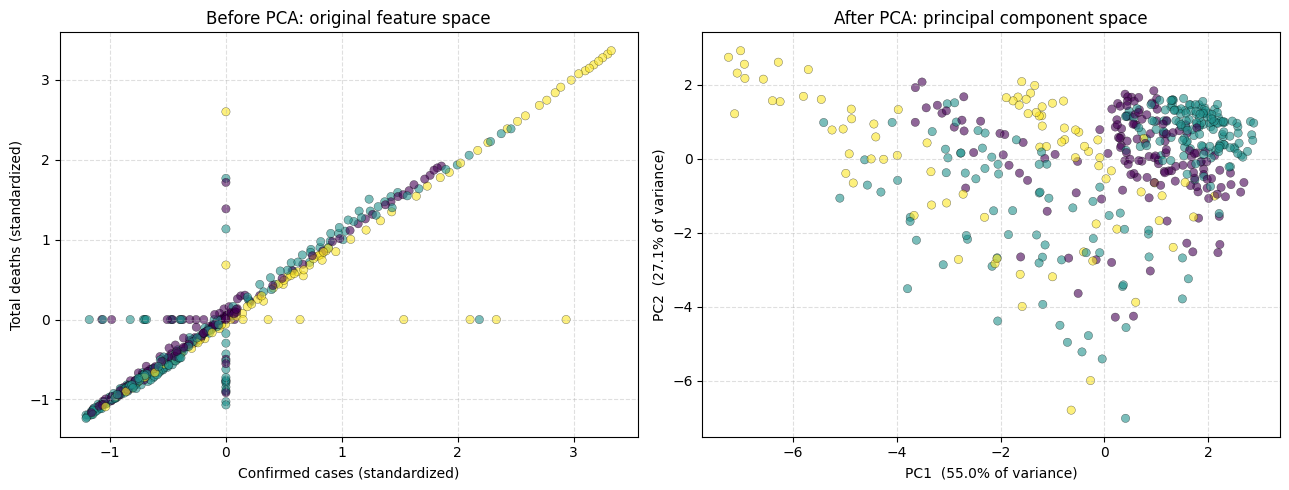

In [25]:
import matplotlib.pyplot as plt

# percent of variance each PC carries (used for the axis labels)
total_var = sorted_eigenvalues.sum()
evr = sorted_eigenvalues / total_var

prov_codes = X[:, 0]   # province codes, for colouring

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# BEFORE: two original features
xi = feature_names.index("confirmed_cases")
yi = feature_names.index("total_deaths")
ax[0].scatter(Z[:, xi], Z[:, yi], c=prov_codes, cmap="viridis",
              alpha=0.6, edgecolors="k", linewidths=0.3)
ax[0].set_title("Before PCA: original feature space")
ax[0].set_xlabel("Confirmed cases (standardized)")
ax[0].set_ylabel("Total deaths (standardized)")
ax[0].grid(True, linestyle="--", alpha=0.4)

# AFTER: principal component space
ax[1].scatter(reduced[:, 0], reduced[:, 1], c=prov_codes, cmap="viridis",
              alpha=0.6, edgecolors="k", linewidths=0.3)
ax[1].set_title("After PCA: principal component space")
ax[1].set_xlabel(f"PC1  ({evr[0]*100:.1f}% of variance)")
ax[1].set_ylabel(f"PC2  ({evr[1]*100:.1f}% of variance)")
ax[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

**1. Interpret the Visual you just created of the before and after PCA**

In the left plot the points fall almost on a straight diagonal line, because confirmed cases and total deaths are strongly correlated and rise together. After PCA the same cloud is rotated onto new axes, where PC1 carries the most spread and roughly tracks how big and how deadly the outbreak became in each health zone. The short vertical and horizontal lines of points sitting near zero are the rows where we filled missing values with the column mean, which lands at zero once standardized. Importantly the overall shape and clusters are preserved, so PCA did not lose or scramble the data. It only turned it to face the direction that holds the most variation.

**2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making**

We looked at the explained variance instead of guessing: PC1 holds about 55% and PC2 about 27%, so two components keep roughly 82% of the information. Our 85% threshold rule actually asks for a third component, which would push the total past 90%. We kept 2 components for the visualization because two axes are all a flat scatter can show, and 82% is already most of the signal. The tradeoff is that dropping the third costs a few percent of variance and some of the finer separation between provinces. So we trade a little accuracy for a chart a human can read, and we would keep 3 if we were feeding a model rather than plotting.

**3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?**

For our DRC Ebola data, the first two components keep the big picture: how large and severe the outbreak was in each health zone, and roughly which province it belonged to. The components we discard hold the smaller details, such as week-to-week reporting noise, late or corrected case counts, and minor differences between zones inside the same province. This means we lose the local, short-term variation, for example one zone having a single slow reporting week. What we keep is the overall macro trend of where and when the outbreak was at its worst. For tracking the epidemic at province level that is an acceptable loss, but for fine local decisions those discarded details would matter.


**Task 2**

In [26]:
# Task 2: Dynamic Explained Variance Calculation
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative = np.cumsum(explained_variance_ratio)

print("Variance explained by each component:")
for i in range(len(explained_variance_ratio)):
    print(f"  PC{i+1}: {explained_variance_ratio[i]*100:5.2f}%   "
          f"(cumulative {cumulative[i]*100:5.2f}%)")

threshold = 0.85
k = int(np.argmax(cumulative >= threshold) + 1)
print(f"\nTo keep at least {threshold*100:.0f}% of the variance we need {k} components.")

Variance explained by each component:
  PC1: 55.02%   (cumulative 55.02%)
  PC2: 27.11%   (cumulative 82.12%)
  PC3:  9.91%   (cumulative 92.03%)
  PC4:  2.92%   (cumulative 94.95%)
  PC5:  1.69%   (cumulative 96.64%)
  PC6:  1.40%   (cumulative 98.05%)
  PC7:  0.80%   (cumulative 98.85%)
  PC8:  0.64%   (cumulative 99.48%)
  PC9:  0.52%   (cumulative 100.00%)

To keep at least 85% of the variance we need 3 components.


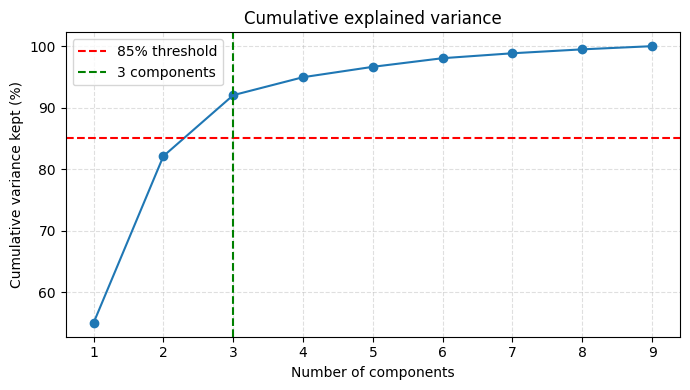

In [27]:
# scree-style plot: cumulative variance vs number of components
plt.figure(figsize=(7, 4))
xs = np.arange(1, len(cumulative) + 1)
plt.plot(xs, cumulative * 100, marker="o")
plt.axhline(85, color="red", linestyle="--", label="85% threshold")
plt.axvline(k, color="green", linestyle="--", label=f"{k} components")
plt.title("Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance kept (%)")
plt.xticks(xs)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Task 3**

In [28]:
import time

def run_pca(matrix, n_components=2):
    """Full PCA pipeline, fully vectorized."""
    m = matrix.mean(axis=0)
    s = matrix.std(axis=0)
    s[s == 0] = 1.0
    z = (matrix - m) / s
    c = np.cov(z.T)
    vals, vecs = np.linalg.eigh(c)
    idx = np.argsort(vals)[::-1]
    vecs = vecs[:, idx[:n_components]]
    return z @ vecs

# time it on our real dataset
start = time.time()
_ = run_pca(X)
print(f"PCA on real data {X.shape}: {(time.time()-start)*1000:.3f} ms")

PCA on real data (454, 9): 1.884 ms


In [29]:
# stress test: stack the data many times to make a big matrix
big = np.tile(X, (500, 1))      # ~500x more rows
print("Large matrix shape:", big.shape)

start = time.time()
_ = run_pca(big)
print(f"PCA on large data {big.shape}: {(time.time()-start)*1000:.3f} ms")

Large matrix shape: (227000, 9)
PCA on large data (227000, 9): 77.564 ms
